In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix

## Read Data

In [2]:
df = pd.read_csv("data/Customer-Churn-Records.csv")

## Data Understanding

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.shape

(10000, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## Data Preprocessing

In [7]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

RowNumber             10000
CustomerId            10000
Surname                2932
CreditScore             460
Geography                 3
Gender                    2
Age                      70
Tenure                   11
Balance                6382
NumOfProducts             4
HasCrCard                 2
IsActiveMember            2
EstimatedSalary        9999
Exited                    2
Complain                  2
Satisfaction Score        5
Card Type                 4
Point Earned            785
dtype: int64

In [10]:
df.drop(columns=["RowNumber","CustomerId","Surname"], inplace=True) #These columns don't provide predictive information

## ERD

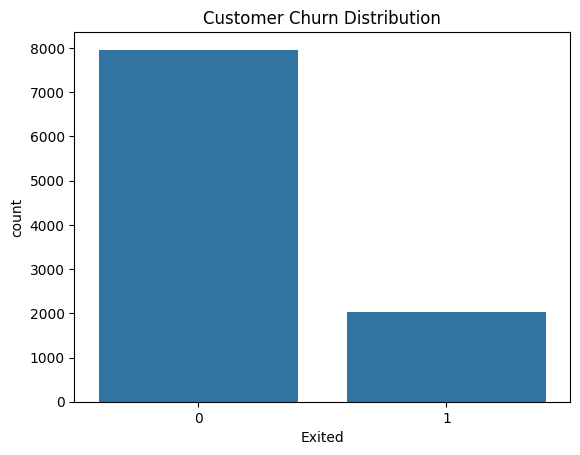

In [11]:
sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution")

plt.show()

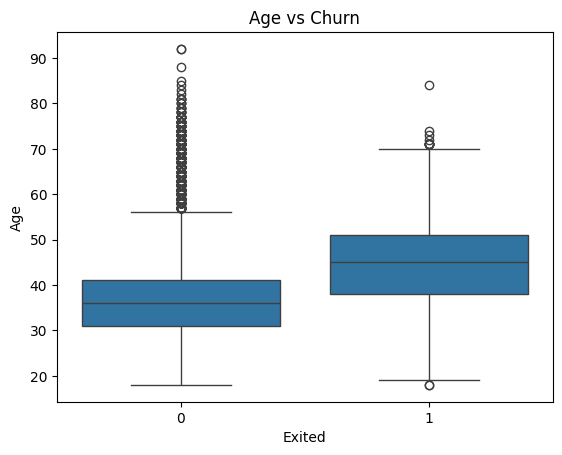

In [12]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")

plt.show()

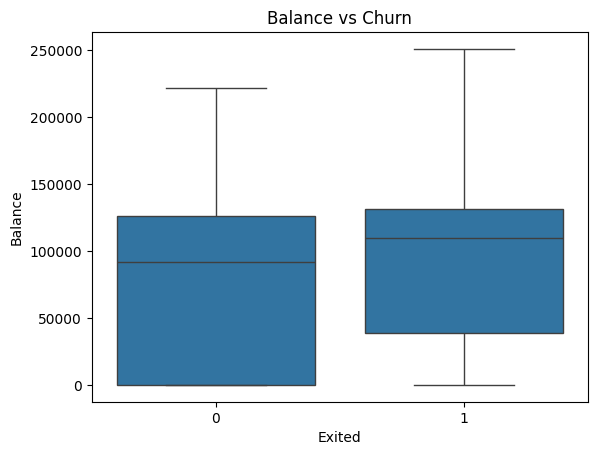

In [13]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn")

plt.show()

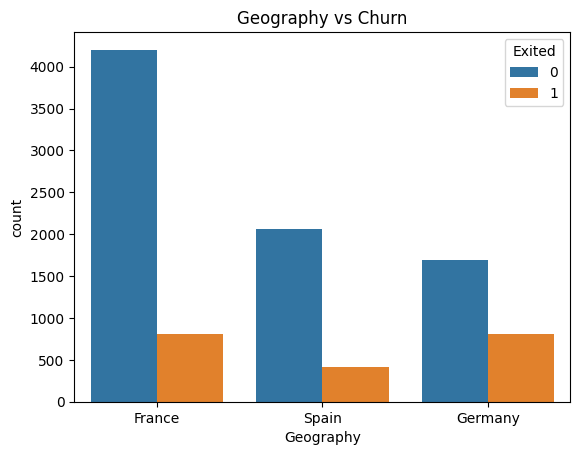

In [14]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Churn")
plt.show()

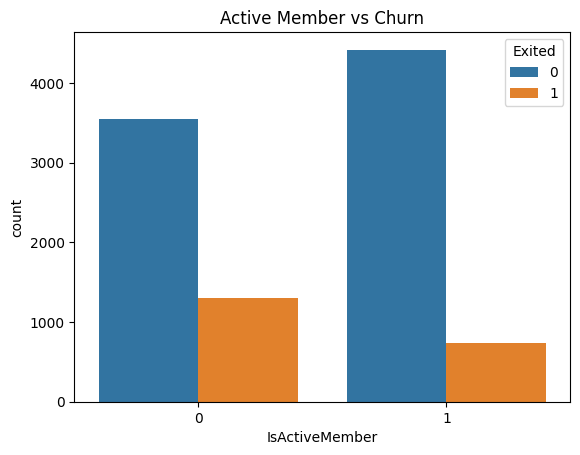

In [15]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title("Active Member vs Churn")
plt.show()

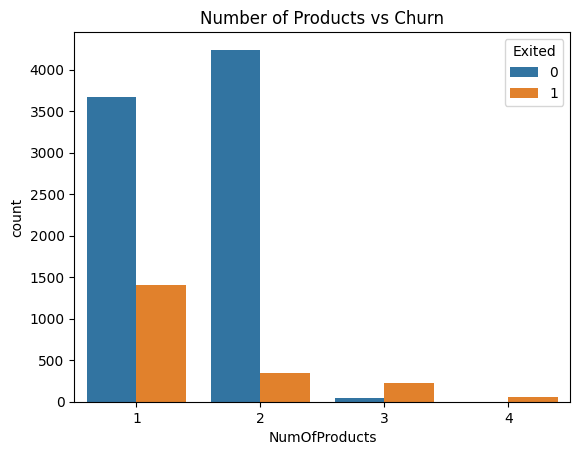

In [16]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title("Number of Products vs Churn")
plt.show()

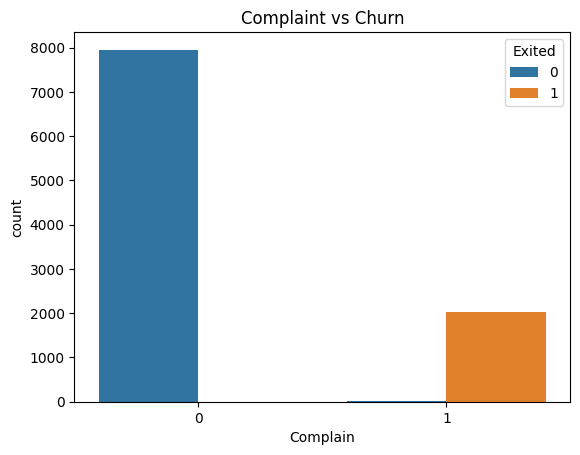

In [17]:
sns.countplot(x='Complain', hue='Exited', data=df)
plt.title("Complaint vs Churn")
plt.show()

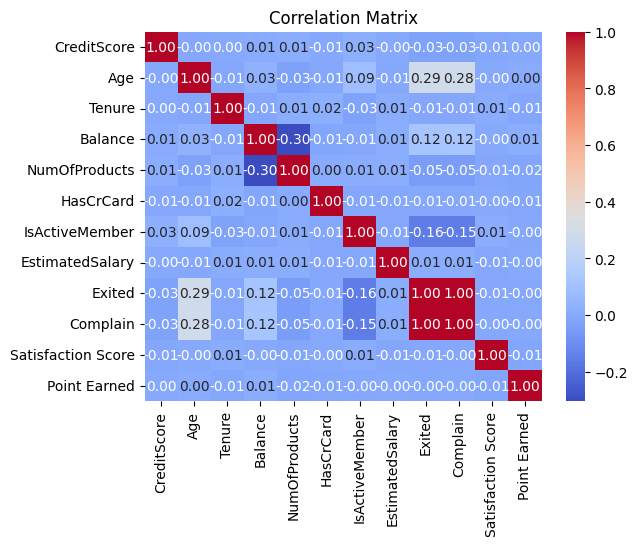

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**EDA Information:**

- **Age:** Older customers are more likely to churn.
- **Balance:** Higher account balances are associated with higher churn.
- **Geography:** Germany has the highest churn rate.
- **IsActiveMember:** Active members are less likely to churn.
- **NumOfProducts:** Customers with fewer products tend to churn more.
- **Complain:** Customers with complaints are more likely to leave.
- **Correlation Analysis:** Age, Complain, and IsActiveMember have the strongest relationship with customer churn.

## Encoding

Categorical features converted into numerical values

In [19]:
df.select_dtypes(include="object").columns

Index(['Geography', 'Gender', 'Card Type'], dtype='object')

In [20]:
df["Gender"] = LabelEncoder().fit_transform(df["Gender"])

In [21]:
df = pd.get_dummies(df,columns=["Geography", "Card Type"],drop_first=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Gender              10000 non-null  int32  
 2   Age                 10000 non-null  int64  
 3   Tenure              10000 non-null  int64  
 4   Balance             10000 non-null  float64
 5   NumOfProducts       10000 non-null  int64  
 6   HasCrCard           10000 non-null  int64  
 7   IsActiveMember      10000 non-null  int64  
 8   EstimatedSalary     10000 non-null  float64
 9   Exited              10000 non-null  int64  
 10  Complain            10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Point Earned        10000 non-null  int64  
 13  Geography_Germany   10000 non-null  bool   
 14  Geography_Spain     10000 non-null  bool   
 15  Card Type_GOLD      10000 non-null  bool   
 16  Card 

## Train-Test Split

In [23]:
X = df.drop(["Exited",'Complain'], axis=1)
y = df["Exited"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

## Model Training

In [25]:
lgb = LGBMClassifier(random_state=42)
lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1123
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [26]:
y_pred = lgb.predict(X_test)
y_prob = lgb.predict_proba(X_test)[:, 1]

In [73]:
joblib.dump(lgb, "churn_model.pkl")

['churn_model.pkl']

## Evaluation

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1592
           1       0.74      0.53      0.62       408

    accuracy                           0.87      2000
   macro avg       0.81      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [28]:
roc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc) #strong ability to distinguish between churn and non-churn customers

ROC AUC: 0.8716375997635235


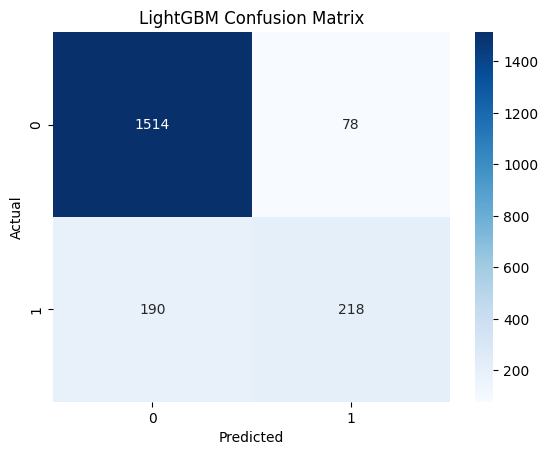

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt="d",cmap="Blues")

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb.feature_importances_
    })

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,Balance,485
0,CreditScore,449
8,EstimatedSalary,441
10,Point Earned,391
2,Age,382
5,NumOfProducts,189
3,Tenure,154
9,Satisfaction Score,120
7,IsActiveMember,90
11,Geography_Germany,74


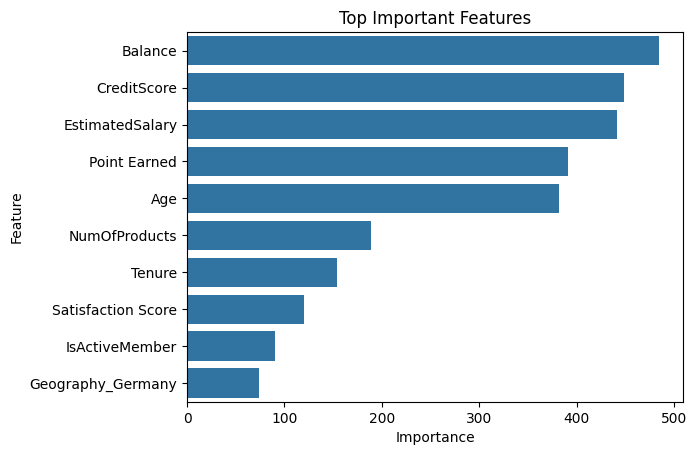

In [31]:
sns.barplot(data=feature_importance.head(10),x="Importance",y="Feature")
plt.title("Top Important Features")

plt.show()